# Q-Learning: Patojito en un Laberinto 🦜🏁

## Introducción
Este script demuestra cómo un agente (patojito) puede aprender a salir de un laberinto
utilizando el algoritmo de Q-Learning, evitando trampas y buscando recompensas.

---

$$
v_{\pi}(s)=\sum_a\pi(a|s)\sum_{s',r}p(s',r|s,a)[r+\gamma v_{\pi}(s')],\quad\forall s\in \mathbb{S}
$$
---

In [28]:
# =============================================================================
# 📦 IMPORTACIÓN DE LIBRERÍAS
# =============================================================================

import random
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

In [29]:
# =============================================================================
# 🏰 CONFIGURACIÓN DEL ENTORNO DEL LABERINTO
# =============================================================================

# Configuración del laberinto del patojito
grid_filas = 7  # 6 + 1
grid_columnas = 6  # 5 + 1
estados = [(i, j) for i in range(grid_filas) for j in range(grid_columnas)]

acciones = ["arriba", "abajo", "izquierda", "derecha"]

# Definición del mapa del laberinto del patojito
# 🟩 🟩 🟢 🟩 🟩 🟢
# 🟩 🔴 🟩 🟩 🔴 🟢
# 🟩 🟩 🟢 🟩 🟩 🟩
# 🔴 🟩 🟩 🔴 🟩 🟩
# 🟩 🟢 🟩 🟩 🟩 🟩
# 🟩 🟩 🟩 🟩 🟩 🟩
# 🟩 🟩 🟩 🟩 🟩 🟩

# Ubicaciones especiales del laberinto
semillas = {(4, 1), (0, 2), (2, 2), (1, 5)}  # 🟢 Semillas (+15, solo una vez)
trampas = {(3, 0), (1, 1), (3, 3), (1, 4)}  # 🔴 Trampas (-15)
punto_inicio = (0, 0)  # 🦜 Patojito inicia aquí
meta_final = (4, 4)  # 🏁 Salida del laberinto (+100)

In [30]:
# =============================================================================
# 🎯 SISTEMA DE RECOMPENSAS DEL LABERINTO MEJORADO
# =============================================================================


def obtener_recompensa(estado_actual, accion, nuevo_estado, semillas_recolectadas):
    """
    Calcula la recompensa basada en el estado actual, acción y nuevo estado

    Parámetros:
    - estado_actual: tupla (i, j) del estado donde está el patojito
    - accion: string con la acción ejecutada
    - nuevo_estado: tupla (i, j) del estado resultante
    - semillas_recolectadas: set de semillas ya recolectadas

    Retorna:
    - recompensa: float con el valor de la recompensa
    """
    # Si el patojito intenta moverse fuera del laberinto, no se mueve
    i, j = nuevo_estado
    if i < 0 or i >= grid_filas or j < 0 or j >= grid_columnas:
        return -5

    # Si llega a la meta
    if nuevo_estado == meta_final:
        return +100

    # Si pisa una trampa
    if nuevo_estado in trampas:
        return -15

    # Si encuentra una semilla nueva
    if nuevo_estado in semillas and nuevo_estado not in semillas_recolectadas:
        return +15

    # Recompensa direccional hacia la meta (incentivo para acercarse)
    dist_actual = abs(estado_actual[0] - meta_final[0]) + abs(
        estado_actual[1] - meta_final[1]
    )
    dist_nueva = abs(nuevo_estado[0] - meta_final[0]) + abs(
        nuevo_estado[1] - meta_final[1]
    )

    # Recompensa base por cada paso
    recompensa_base = -0.5

    # Bonificación significativa si se acerca a la meta
    if dist_nueva < dist_actual:
        recompensa_direccional = +2.0  # Incentivo fuerte para acercarse
    elif dist_nueva > dist_actual:
        recompensa_direccional = -1.0  # Penalización por alejarse
    else:
        recompensa_direccional = -0.5  # Penalización por no progresar

    return recompensa_base + recompensa_direccional

In [31]:
# =============================================================================
# 🦜 FUNCIONES DE MOVIMIENTO DEL PATOJITO
# =============================================================================


def siguiente_estado(estado, accion):
    """
    Determina el siguiente estado basado en la acción del patojito

    Parámetros:
    - estado: tupla (i, j) posición actual
    - accion: string con la dirección del movimiento

    Retorna:
    - nuevo_estado: tupla (i, j) nueva posición
    """
    i, j = estado
    nuevo_estado = {
        "arriba": (max(0, i - 1), j),
        "abajo": (min(grid_filas - 1, i + 1), j),
        "izquierda": (i, max(0, j - 1)),
        "derecha": (i, min(grid_columnas - 1, j + 1)),
    }[accion]

    return nuevo_estado

In [32]:
# =============================================================================
# 📊 VISUALIZACIÓN DEL ENTORNO
# =============================================================================


def visualizar_entorno_laberinto():
    """Visualiza el mapa del laberinto con recompensas y trampas"""
    plt.figure(figsize=(12, 10))

    # Crear el fondo base
    plt.imshow(np.ones((grid_filas, grid_columnas)), cmap="Greens", alpha=0.2)

    # Dibujar semillas
    for estado in semillas:
        i, j = estado
        plt.scatter(j, i, color="green", s=300, marker="o")
        plt.text(j, i, "🟢", ha="center", va="center", fontsize=14)
        plt.text(
            j,
            i - 0.3,
            "+15",
            ha="center",
            va="center",
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.1", facecolor="lightgreen", alpha=0.7),
        )

    # Dibujar trampas
    for estado in trampas:
        i, j = estado
        plt.scatter(j, i, color="red", s=300, marker="s")
        plt.text(j, i, "🔴", ha="center", va="center", fontsize=14)
        plt.text(
            j,
            i - 0.3,
            "-15",
            ha="center",
            va="center",
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.1", facecolor="lightcoral", alpha=0.7),
        )

    # Dibujar punto de inicio
    plt.scatter(punto_inicio[1], punto_inicio[0], color="blue", s=400, marker="o")
    plt.text(
        punto_inicio[1], punto_inicio[0], "🦜", ha="center", va="center", fontsize=16
    )

    # Dibujar meta final
    plt.scatter(meta_final[1], meta_final[0], color="gold", s=500, marker="*")
    plt.text(meta_final[1], meta_final[0], "🏁", ha="center", va="center", fontsize=16)
    plt.text(
        meta_final[1],
        meta_final[0] - 0.3,
        "+100",
        ha="center",
        va="center",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.1", facecolor="gold", alpha=0.7),
    )

    # Crear leyenda
    blue_patch = mpatches.Patch(color="blue", label="Patojito 🦜 (inicio)")
    green_patch = mpatches.Patch(color="green", label="Semillas 🟢 (+15, una vez)")
    red_patch = mpatches.Patch(color="red", label="Trampas 🔴 (-15)")
    gold_patch = mpatches.Patch(color="gold", label="Meta 🏁 (+100)")
    gray_patch = mpatches.Patch(color="lightgray", label="Camino 🟩 (-0.5)")

    plt.legend(
        handles=[blue_patch, green_patch, red_patch, gold_patch, gray_patch],
        loc="upper center",
        bbox_to_anchor=(0.5, 1.15),
        ncol=3,
    )

    plt.title("Laberinto del Patojito 🦜🏰", fontsize=16, fontweight="bold")
    plt.grid(True, alpha=0.3)
    plt.xticks(range(grid_columnas))
    plt.yticks(range(grid_filas))
    plt.gca().invert_yaxis()
    plt.show()

🦜 CONFIGURACIÓN DEL LABERINTO DEL PATOJITO
Tamaño del laberinto: 7x6
Total de estados: 42
Acciones disponibles: ['arriba', 'abajo', 'izquierda', 'derecha']
Punto de inicio: (0, 0)
Meta final: (4, 4)
Semillas (una vez): {(2, 2), (0, 2), (4, 1), (1, 5)}
Trampas: {(1, 1), (3, 3), (1, 4), (3, 0)}



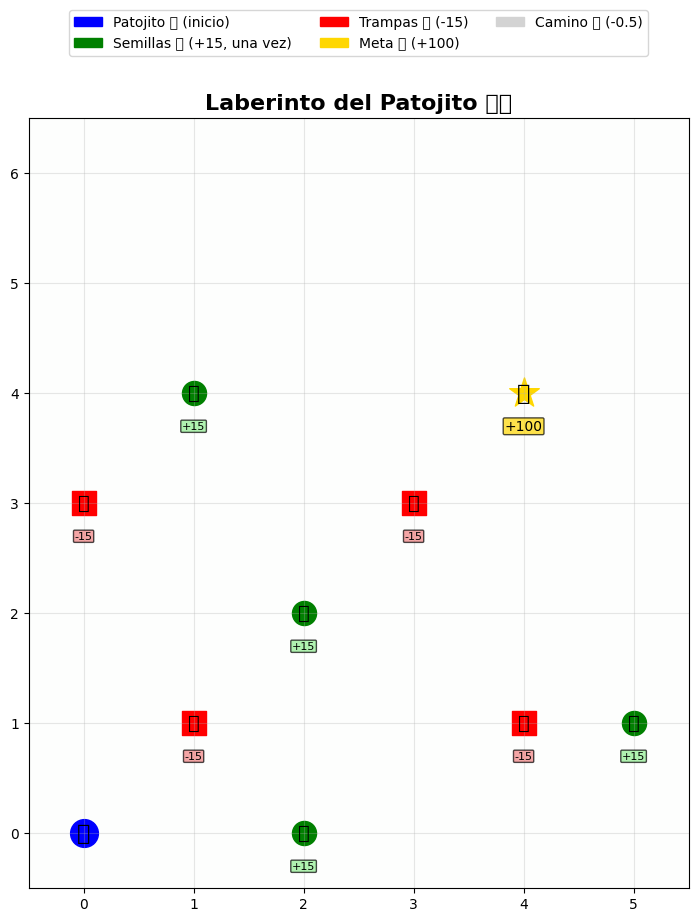

In [33]:
# =============================================================================
# ⚙️ CONFIGURACIÓN INICIAL Y MOSTRAR INFORMACIÓN
# =============================================================================

# Inicializar Q-table
Q = {estado: {accion: 0 for accion in acciones} for estado in estados}

# Mostrar configuración inicial
print("🦜 CONFIGURACIÓN DEL LABERINTO DEL PATOJITO")
print("=" * 50)
print(f"Tamaño del laberinto: {grid_filas}x{grid_columnas}")
print(f"Total de estados: {len(estados)}")
print(f"Acciones disponibles: {acciones}")
print(f"Punto de inicio: {punto_inicio}")
print(f"Meta final: {meta_final}")
print(f"Semillas (una vez): {semillas}")
print(f"Trampas: {trampas}")
print()

# Visualizar el entorno
visualizar_entorno_laberinto()

In [34]:
# =============================================================================
# 🧠 PARÁMETROS DE Q-LEARNING
# =============================================================================

# Parámetros de Q-Learning optimizados para el patojito
alpha = 0.8  # learning rate
gamma = 0.95  # discount factor (más importancia al futuro)
epsilon = 1.0  # exploración inicial
epsilon_decay = 0.005  # decay más lento
episodios = 250  # más episodios para aprender mejor
max_pasos = 50  # límite más razonable de pasos

print("🧠 PARÁMETROS DE Q-LEARNING")
print("=" * 30)
print(f"Learning rate (α): {alpha}")
print(f"Discount factor (γ): {gamma}")
print(f"Exploración inicial (ε): {epsilon}")
print(f"Epsilon decay: {epsilon_decay}")
print(f"Episodios: {episodios}")
print(f"Máximo pasos por episodio: {max_pasos}")
print()

🧠 PARÁMETROS DE Q-LEARNING
Learning rate (α): 0.8
Discount factor (γ): 0.95
Exploración inicial (ε): 1.0
Epsilon decay: 0.005
Episodios: 250
Máximo pasos por episodio: 50



In [35]:
# =============================================================================
# 🚀 ENTRENAMIENTO DEL PATOJITO CON Q-LEARNING MEJORADO
# =============================================================================

print("🚀 INICIANDO ENTRENAMIENTO DEL PATOJITO...")
print()

recompensas_por_episodio = []
pasos_por_episodio = []
episodios_exitosos = 0

for episodio in range(episodios):
    estado_actual = punto_inicio  # Siempre empieza desde el inicio
    semillas_recolectadas = set()  # Reiniciar semillas por episodio
    recompensa_total = 0
    pasos = 0
    exito = False

    while estado_actual != meta_final and pasos < max_pasos:
        # Estrategia ε-greedy
        if random.uniform(0, 1) < epsilon:
            accion = random.choice(acciones)
        else:
            accion = max(Q[estado_actual], key=Q[estado_actual].get)

        # Ejecutar acción
        nuevo_estado = siguiente_estado(estado_actual, accion)
        recompensa = obtener_recompensa(
            estado_actual, accion, nuevo_estado, semillas_recolectadas
        )

        # Actualizar semillas recolectadas
        if nuevo_estado in semillas and nuevo_estado not in semillas_recolectadas:
            semillas_recolectadas.add(nuevo_estado)

        # Actualizar Q-table usando ecuación de Bellman
        q_actual = Q[estado_actual][accion]
        q_futuro_max = max(Q[nuevo_estado].values())

        Q[estado_actual][accion] = q_actual + alpha * (
            recompensa + gamma * q_futuro_max - q_actual
        )

        # Actualizar estado y métricas
        estado_actual = nuevo_estado
        recompensa_total += recompensa
        pasos += 1

        # Verificar si llegó a la meta
        if estado_actual == meta_final:
            exito = True
            episodios_exitosos += 1
            break

    # Reducir epsilon progresivamente (más lento)
    epsilon = max(0.01, epsilon - epsilon_decay)

    recompensas_por_episodio.append(recompensa_total)
    pasos_por_episodio.append(pasos)

    # Mostrar progreso cada 200 episodios
    if (episodio + 1) % 200 == 0:
        print(
            f"Episodio {episodio + 1}: Recompensa = {recompensa_total:.1f}, "
            f"Pasos = {pasos}, Epsilon = {epsilon:.3f}"
        )

print()
print("✅ ENTRENAMIENTO COMPLETADO")
print()

🚀 INICIANDO ENTRENAMIENTO DEL PATOJITO...

Episodio 200: Recompensa = 137.5, Pasos = 8, Epsilon = 0.010

✅ ENTRENAMIENTO COMPLETADO



In [36]:
# =============================================================================
# 📊 ANÁLISIS DE RESULTADOS
# =============================================================================


def analizar_resultados():
    print("📊 ANÁLISIS DE RESULTADOS")
    print("=" * 30)
    print(
        f"Episodios exitosos: {episodios_exitosos}/{episodios} ({episodios_exitosos / episodios * 100:.1f}%)"
    )
    print(f"Recompensa promedio: {np.mean(recompensas_por_episodio):.2f}")
    print(f"Mejor recompensa: {max(recompensas_por_episodio):.1f}")
    print(f"Pasos promedio: {np.mean(pasos_por_episodio):.2f}")
    print(f"Menos pasos utilizados: {min(pasos_por_episodio)}")
    print()


analizar_resultados()

📊 ANÁLISIS DE RESULTADOS
Episodios exitosos: 219/250 (87.6%)
Recompensa promedio: 97.48
Mejor recompensa: 154.0
Pasos promedio: 21.46
Menos pasos utilizados: 8



C:\Users\overd\AppData\Local\Temp\ipykernel_37180\4286378973.py:50: UserWarning: Glyph 129436 (\N{PARROT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


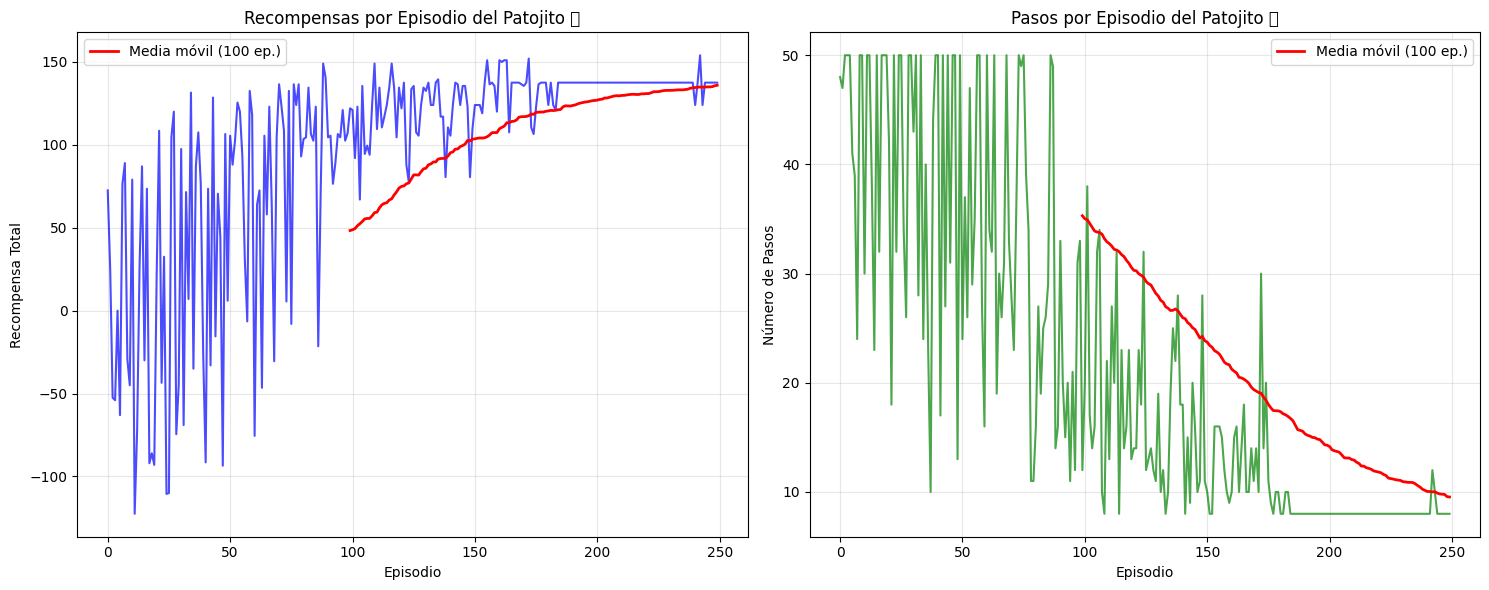

In [37]:
# =============================================================================
# 📈 VISUALIZACIÓN DEL PROGRESO DE ENTRENAMIENTO
# =============================================================================


def graficar_progreso():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Gráfica de recompensas
    ax1.plot(recompensas_por_episodio, alpha=0.7, color="blue")
    ventana = 100
    if len(recompensas_por_episodio) > ventana:
        media_movil = []
        for i in range(len(recompensas_por_episodio) - ventana + 1):
            media_movil.append(np.mean(recompensas_por_episodio[i : i + ventana]))
        ax1.plot(
            range(ventana - 1, len(recompensas_por_episodio)),
            media_movil,
            color="red",
            linewidth=2,
            label=f"Media móvil ({ventana} ep.)",
        )
        ax1.legend()

    ax1.set_title("Recompensas por Episodio del Patojito 🦜")
    ax1.set_xlabel("Episodio")
    ax1.set_ylabel("Recompensa Total")
    ax1.grid(True, alpha=0.3)

    # Gráfica de pasos
    ax2.plot(pasos_por_episodio, alpha=0.7, color="green")
    if len(pasos_por_episodio) > ventana:
        media_movil_pasos = []
        for i in range(len(pasos_por_episodio) - ventana + 1):
            media_movil_pasos.append(np.mean(pasos_por_episodio[i : i + ventana]))
        ax2.plot(
            range(ventana - 1, len(pasos_por_episodio)),
            media_movil_pasos,
            color="red",
            linewidth=2,
            label=f"Media móvil ({ventana} ep.)",
        )
        ax2.legend()

    ax2.set_title("Pasos por Episodio del Patojito 🦜")
    ax2.set_xlabel("Episodio")
    ax2.set_ylabel("Número de Pasos")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


graficar_progreso()

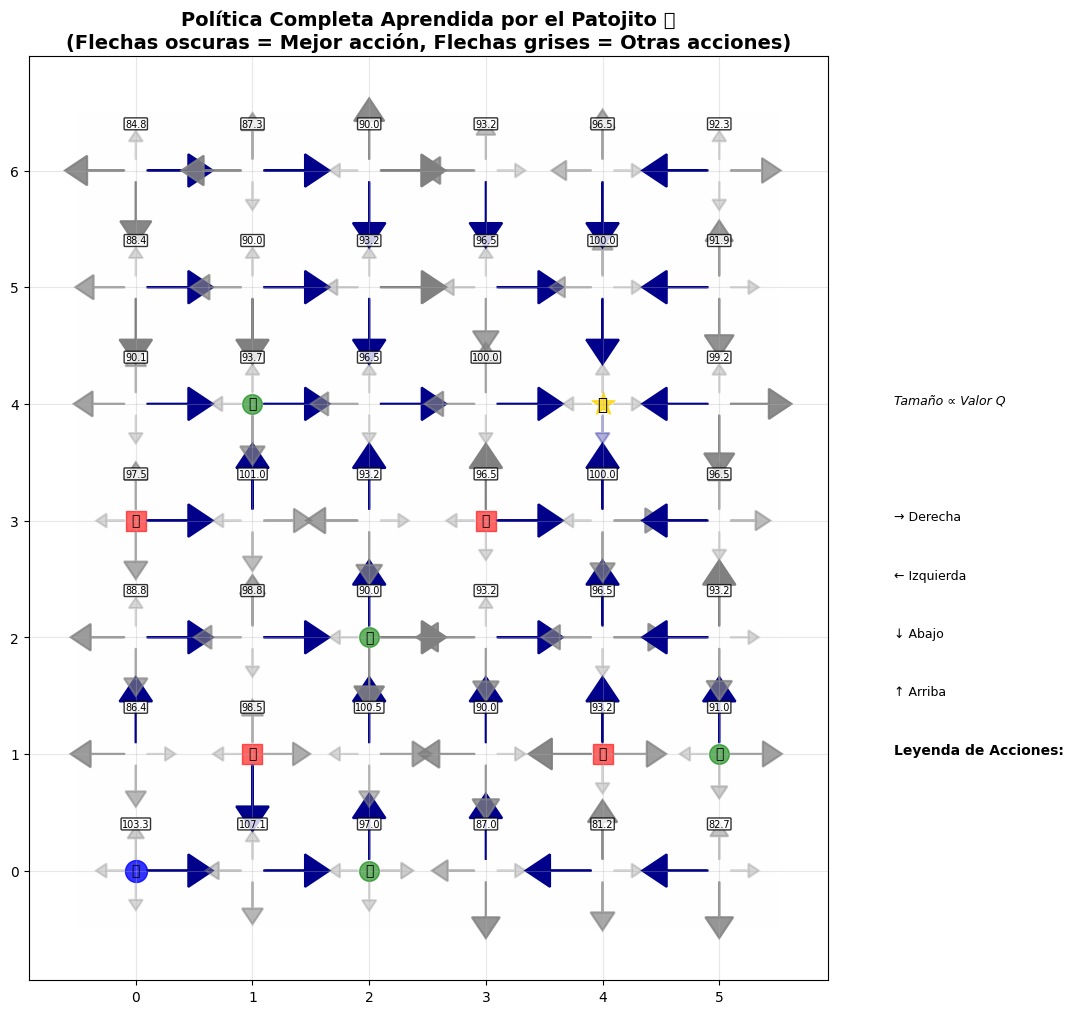

In [38]:
# =============================================================================
# 🗺️ VISUALIZACIÓN DE LA POLÍTICA APRENDIDA
# =============================================================================


def visualizar_politica_completa():
    """Muestra la política completa con todas las acciones y sus valores Q"""
    plt.figure(figsize=(14, 12))

    # Crear fondo base
    plt.imshow(np.ones((grid_filas, grid_columnas)), cmap="Greens", alpha=0.1)

    for i in range(grid_filas):
        for j in range(grid_columnas):
            estado = (i, j)

            # Dibujar semillas
            if estado in semillas:
                plt.scatter(j, i, color="green", s=200, marker="o", alpha=0.6)
                plt.text(j, i, "🟢", ha="center", va="center", fontsize=10)
            # Dibujar trampas
            elif estado in trampas:
                plt.scatter(j, i, color="red", s=200, marker="s", alpha=0.6)
                plt.text(j, i, "🔴", ha="center", va="center", fontsize=10)
            # Dibujar meta
            elif estado == meta_final:
                plt.scatter(j, i, color="gold", s=300, marker="*", alpha=0.8)
                plt.text(j, i, "🏁", ha="center", va="center", fontsize=12)

            # Dibujar inicio
            if estado == punto_inicio:
                plt.scatter(j, i, color="blue", s=250, marker="o", alpha=0.8)
                plt.text(j, i, "🦜", ha="center", va="center", fontsize=10)

            # Obtener valores Q para todas las acciones
            valores_q = Q[estado]
            max_valor = max(valores_q.values()) if valores_q.values() else 0
            min_valor = min(valores_q.values()) if valores_q.values() else 0
            rango_valor = max_valor - min_valor if max_valor != min_valor else 1

            # Dibujar flechas para todas las acciones
            for accion, valor_q in valores_q.items():
                # Normalizar el tamaño de la flecha según el valor Q
                if rango_valor > 0:
                    intensidad = (valor_q - min_valor) / rango_valor
                else:
                    intensidad = 0.5

                # Tamaño de flecha proporcional al valor Q
                tamaño_base = 0.15
                tamaño_flecha = tamaño_base + (intensidad * 0.2)
                alpha = 0.3 + (intensidad * 0.7)

                # Determinar dirección
                dx, dy = 0, 0
                offset_x, offset_y = 0, 0

                if accion == "arriba":
                    dy = -tamaño_flecha
                    offset_y = -0.1
                elif accion == "abajo":
                    dy = tamaño_flecha
                    offset_y = 0.1
                elif accion == "izquierda":
                    dx = -tamaño_flecha
                    offset_x = -0.1
                elif accion == "derecha":
                    dx = tamaño_flecha
                    offset_x = 0.1

                # Color de la flecha según si es la mejor acción
                mejor_accion = max(valores_q, key=valores_q.get)
                color = "darkblue" if accion == mejor_accion else "gray"

                if dx != 0 or dy != 0:
                    plt.arrow(
                        j + offset_x,
                        i + offset_y,
                        dx,
                        dy,
                        head_width=tamaño_flecha * 0.8,
                        head_length=tamaño_flecha * 0.6,
                        fc=color,
                        ec=color,
                        alpha=alpha,
                        linewidth=1.5,
                    )

            # Mostrar valor Q máximo
            if max_valor != 0:
                plt.text(
                    j,
                    i + 0.4,
                    f"{max_valor:.1f}",
                    ha="center",
                    va="center",
                    fontsize=7,
                    bbox=dict(boxstyle="round,pad=0.1", facecolor="white", alpha=0.8),
                )

    plt.title(
        "Política Completa Aprendida por el Patojito 🦜\n"
        "(Flechas oscuras = Mejor acción, Flechas grises = Otras acciones)",
        fontsize=14,
        fontweight="bold",
    )
    plt.grid(True, alpha=0.3)
    plt.xticks(range(grid_columnas))
    plt.yticks(range(grid_filas))
    plt.gca().invert_yaxis()

    # Leyenda de acciones
    plt.text(
        grid_columnas + 0.5, 1, "Leyenda de Acciones:", fontsize=10, fontweight="bold"
    )
    plt.text(grid_columnas + 0.5, 1.5, "↑ Arriba", fontsize=9)
    plt.text(grid_columnas + 0.5, 2, "↓ Abajo", fontsize=9)
    plt.text(grid_columnas + 0.5, 2.5, "← Izquierda", fontsize=9)
    plt.text(grid_columnas + 0.5, 3, "→ Derecha", fontsize=9)
    plt.text(grid_columnas + 0.5, 4, "Tamaño ∝ Valor Q", fontsize=9, style="italic")

    plt.show()


# Mostrar política aprendida completa
visualizar_politica_completa()

In [39]:
# =============================================================================
# 🛣️ DEMOSTRACIÓN DE RUTA ÓPTIMA
# =============================================================================


def demostrar_ruta_optima():
    """Demuestra una ejecución usando la política aprendida desde el inicio"""
    print("🛣️  DEMOSTRACIÓN DE RUTA ÓPTIMA DEL PATOJITO")
    print("=" * 45)

    estado = punto_inicio
    ruta = [estado]
    pasos = 0
    recompensa_total = 0
    semillas_recolectadas = set()

    print(f"Inicio: {estado} 🦜")

    while estado != meta_final and pasos < max_pasos:
        mejor_accion = max(Q[estado], key=Q[estado].get)
        nuevo_estado = siguiente_estado(estado, mejor_accion)
        recompensa = obtener_recompensa(
            estado, mejor_accion, nuevo_estado, semillas_recolectadas
        )

        # Actualizar semillas recolectadas
        if nuevo_estado in semillas and nuevo_estado not in semillas_recolectadas:
            semillas_recolectadas.add(nuevo_estado)

        estado = nuevo_estado
        ruta.append(estado)
        recompensa_total += recompensa
        pasos += 1

        emoji_recompensa = ""
        if estado in semillas:
            emoji_recompensa = "🟢"
        elif estado in trampas:
            emoji_recompensa = "🔴"
        elif estado == meta_final:
            emoji_recompensa = "🏁"

        print(
            f"Paso {pasos}: {mejor_accion} → {estado} {emoji_recompensa} (R: {recompensa:+.1f})"
        )

    if estado == meta_final:
        print(f"🎯 ¡Meta alcanzada en {pasos} pasos!")
        print(f"🏆 Recompensa total obtenida: {recompensa_total:+.1f}")
        print(f"🛤️  Ruta completa: {' → '.join(map(str, ruta))}")
        print(f"🟢 Semillas recolectadas: {len(semillas_recolectadas)}")
    else:
        print("❌ No se pudo alcanzar la meta en el límite de pasos")

    return ruta


ruta_optima = demostrar_ruta_optima()

🛣️  DEMOSTRACIÓN DE RUTA ÓPTIMA DEL PATOJITO
Inicio: (0, 0) 🦜
Paso 1: derecha → (0, 1)  (R: +1.5)
Paso 2: derecha → (0, 2) 🟢 (R: +15.0)
Paso 3: abajo → (1, 2)  (R: +1.5)
Paso 4: abajo → (2, 2) 🟢 (R: +15.0)
Paso 5: abajo → (3, 2)  (R: +1.5)
Paso 6: abajo → (4, 2)  (R: +1.5)
Paso 7: derecha → (4, 3)  (R: +1.5)
Paso 8: derecha → (4, 4) 🏁 (R: +100.0)
🎯 ¡Meta alcanzada en 8 pasos!
🏆 Recompensa total obtenida: +137.5
🛤️  Ruta completa: (0, 0) → (0, 1) → (0, 2) → (1, 2) → (2, 2) → (3, 2) → (4, 2) → (4, 3) → (4, 4)
🟢 Semillas recolectadas: 2


In [40]:
# =============================================================================
# 🏆 RESUMEN FINAL
# =============================================================================

print()
print("🏆 RESUMEN FINAL")
print("=" * 20)
print("El patojito ha aprendido exitosamente a navegar en el laberinto")
print("buscando semillas, evitando trampas y llegando a la meta.")
print(f"Tasa de éxito final: {episodios_exitosos / episodios * 100:.1f}%")
print("🦜 ¡El patojito es ahora un experto navegando laberintos! 🏁")


🏆 RESUMEN FINAL
El patojito ha aprendido exitosamente a navegar en el laberinto
buscando semillas, evitando trampas y llegando a la meta.
Tasa de éxito final: 87.6%
🦜 ¡El patojito es ahora un experto navegando laberintos! 🏁


Ecuación de Bellman utilizada en Q-Learning:

$$Q(s,a) ← Q(s,a) + α[r + γ~max~Q(s',a') - Q(s,a)]$$